In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [8]:
df= pd.read_csv("consumer_price_index.csv")

In [9]:
df

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Housing,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
0,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,NaN,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1
1,Urban,2013,January,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,100.3,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0
2,Rural+Urban,2013,January,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,100.3,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6
3,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,NaN,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8
4,Urban,2013,February,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,100.4,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,Rural,2025,October,197.2,224.2,196.6,190.9,202.4,208.4,196.6,...,NaN,183.8,189.0,206.2,178.2,182.9,197.6,254.9,201.4,199.0
457,Urban,2025,October,197.9,236.5,201.8,193.3,185.0,205.9,240.4,...,188.1,174.5,182.4,200.9,166.9,178.7,194.8,255.7,191.0,195.4
458,Rural+Urban,2025,October,197.4,228.5,198.6,191.8,196.0,207.2,211.5,...,188.1,180.3,185.9,204.2,172.3,180.5,196.0,255.2,196.4,197.3
459,Rural,2025,November,197.4,225.2,207.5,191.1,202.4,205.7,201.3,...,NaN,184.4,189.3,206.5,178.4,183.1,197.7,255.9,201.7,199.6


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               461 non-null    object 
 1   Year                                 461 non-null    int64  
 2   Month                                461 non-null    object 
 3   Cereals and products                 458 non-null    float64
 4   Meat and fish                        455 non-null    float64
 5   Egg                                  458 non-null    float64
 6   Milk and products                    458 non-null    float64
 7   Oils and fats                        458 non-null    float64
 8   Fruits                               458 non-null    float64
 9   Vegetables                           458 non-null    float64
 10  Pulses and products                  458 non-null    float64
 11  Sugar and Confectionery         

In [12]:
df.isnull()

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Housing,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
457,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
459,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     3
Meat and fish                            6
Egg                                      3
Milk and products                        3
Oils and fats                            3
Fruits                                   3
Vegetables                               3
Pulses and products                      3
Sugar and Confectionery                  3
Spices                                   3
Non-alcoholic beverages                  3
Prepared meals, snacks, sweets etc.      6
Food and beverages                       3
Pan, tobacco and intoxicants             6
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                156
Fuel and light                           3
Household goods and services             6
Health     

In [16]:
df['Cereals and products'].mode()[0]

np.float64(124.0)

In [17]:
 ## Replace the missing values with mode
df['Cereals and products']=df['Cereals and products'].fillna(df['Cereals and products'].mode()[0])

In [18]:
df.isnull().sum()

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     0
Meat and fish                            6
Egg                                      3
Milk and products                        3
Oils and fats                            3
Fruits                                   3
Vegetables                               3
Pulses and products                      3
Sugar and Confectionery                  3
Spices                                   3
Non-alcoholic beverages                  3
Prepared meals, snacks, sweets etc.      6
Food and beverages                       3
Pan, tobacco and intoxicants             6
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                156
Fuel and light                           3
Household goods and services             6
Health     

In [20]:
df['Meat and fish'].mode()[0]

np.float64(143.7)

In [21]:
 ## Replace the missing values with mode
df['Meat and fish']=df['Meat and fish'].fillna(df['Meat and fish'].mode()[0])

In [22]:
df.isnull().sum()

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     0
Meat and fish                            0
Egg                                      3
Milk and products                        3
Oils and fats                            3
Fruits                                   3
Vegetables                               3
Pulses and products                      3
Sugar and Confectionery                  3
Spices                                   3
Non-alcoholic beverages                  3
Prepared meals, snacks, sweets etc.      6
Food and beverages                       3
Pan, tobacco and intoxicants             6
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                156
Fuel and light                           3
Household goods and services             6
Health     

In [23]:
df['Egg'].mode()[0]

np.float64(117.8)

In [25]:
 ## Replace the missing values with mode
df['Egg']=df['Egg'].fillna(df['Egg'].mode()[0])

In [26]:
 ## Replace the missing values with mode
df['Milk and products']=df['Milk and products'].fillna(df['Milk and products'].mode()[0])

In [28]:
 ## Replace the missing values with mode
df['Oils and fats']=df['Oils and fats'].fillna(df['Oils and fats'].mode()[0])

In [30]:
 ## Replace the missing values with mode
df['Oils and fats']=df['Oils and fats'].fillna(df['Oils and fats'].mode()[0])

 ## Replace the missing values with mode
df['Fruits']=df['Fruits'].fillna(df['Fruits'].mode()[0])

 ## Replace the missing values with mode
df['Vegetables']=df['Vegetables'].fillna(df['Vegetables'].mode()[0])

 ## Replace the missing values with mode
df['Pulses and products']=df['Pulses and products'].fillna(df['Pulses and products'].mode()[0])

 ## Replace the missing values with mode
df['Sugar and Confectionery']=df['Sugar and Confectionery'].fillna(df['Sugar and Confectionery'].mode()[0])

 ## Replace the missing values with mode
df['Spices']=df['Spices'].fillna(df['Spices'].mode()[0])





In [31]:
df.isnull().sum()

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     0
Meat and fish                            0
Egg                                      0
Milk and products                        0
Oils and fats                            0
Fruits                                   0
Vegetables                               0
Pulses and products                      0
Sugar and Confectionery                  0
Spices                                   0
Non-alcoholic beverages                  3
Prepared meals, snacks, sweets etc.      6
Food and beverages                       3
Pan, tobacco and intoxicants             6
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                156
Fuel and light                           3
Household goods and services             6
Health     

In [35]:
 ## Replace the missing values with mode
df['Non-alcoholic beverages']=df['Non-alcoholic beverages'].fillna(df['Non-alcoholic beverages'].mode()[0])

 ## Replace the missing values with mode
df['Prepared meals, snacks, sweets etc.']=df['Prepared meals, snacks, sweets etc.'].fillna(df['Prepared meals, snacks, sweets etc.'].mode()[0])

 ## Replace the missing values with mode
df['Food and beverages']=df['Food and beverages'].fillna(df['Food and beverages'].mode()[0])

 ## Replace the missing values with mode
df['Pan, tobacco and intoxicants']=df['Pan, tobacco and intoxicants'].fillna(df['Pan, tobacco and intoxicants'].mode()[0])


In [36]:
df.isnull().sum()

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     0
Meat and fish                            0
Egg                                      0
Milk and products                        0
Oils and fats                            0
Fruits                                   0
Vegetables                               0
Pulses and products                      0
Sugar and Confectionery                  0
Spices                                   0
Non-alcoholic beverages                  0
Prepared meals, snacks, sweets etc.      0
Food and beverages                       0
Pan, tobacco and intoxicants             0
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                156
Fuel and light                           3
Household goods and services             6
Health     

In [37]:
 ## Replace the missing values with mode
df['Clothing']=df['Clothing'].fillna(df['Non-alcoholic beverages'].mode()[0])

 ## Replace the missing values with mode
df['Prepared meals, snacks, sweets etc.']=df['Prepared meals, snacks, sweets etc.'].fillna(df['Prepared meals, snacks, sweets etc.'].mode()[0])

 ## Replace the missing values with mode
df['Footwear']=df['Footwear'].fillna(df['Footwear'].mode()[0])

 ## Replace the missing values with mode
df['Clothing and footwear']=df['Clothing and footwear'].fillna(df['Clothing and footwear'].mode()[0])



In [38]:
df.isnull().sum()

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     0
Meat and fish                            0
Egg                                      0
Milk and products                        0
Oils and fats                            0
Fruits                                   0
Vegetables                               0
Pulses and products                      0
Sugar and Confectionery                  0
Spices                                   0
Non-alcoholic beverages                  0
Prepared meals, snacks, sweets etc.      0
Food and beverages                       0
Pan, tobacco and intoxicants             0
Clothing                                 0
Footwear                                 0
Clothing and footwear                    0
Housing                                156
Fuel and light                           3
Household goods and services             6
Health     

In [41]:
 ## Replace the missing values with mode
df['Housing']=df['Housing'].fillna(df['Housing'].mode()[0])

 ## Replace the missing values with mode
df['Fuel and light']=df['Fuel and light'].fillna(df['Fuel and light'].mode()[0])

 ## Replace the missing values with mode
df['Household goods and services']=df['Household goods and services'].fillna(df['Household goods and services'].mode()[0])

 ## Replace the missing values with mode
df['Health']=df['Health'].fillna(df['Health'].mode()[0])



In [42]:
df.isnull().sum()

Sector                                 0
Year                                   0
Month                                  0
Cereals and products                   0
Meat and fish                          0
Egg                                    0
Milk and products                      0
Oils and fats                          0
Fruits                                 0
Vegetables                             0
Pulses and products                    0
Sugar and Confectionery                0
Spices                                 0
Non-alcoholic beverages                0
Prepared meals, snacks, sweets etc.    0
Food and beverages                     0
Pan, tobacco and intoxicants           0
Clothing                               0
Footwear                               0
Clothing and footwear                  0
Housing                                0
Fuel and light                         0
Household goods and services           0
Health                                 0
Transport and co

In [43]:
 ## Replace the missing values with mode
df['Transport and communication']=df['Transport and communication'].fillna(df['Transport and communication'].mode()[0])

 ## Replace the missing values with mode
df['Recreation and amusement']=df['Recreation and amusement'].fillna(df['Recreation and amusement'].mode()[0])

 ## Replace the missing values with mode
df['Education']=df['Education'].fillna(df['Education'].mode()[0])

 ## Replace the missing values with mode
df['Personal care and effects']=df['Personal care and effects'].fillna(df['Personal care and effects'].mode()[0])



In [44]:
df.isnull().sum()

Sector                                 0
Year                                   0
Month                                  0
Cereals and products                   0
Meat and fish                          0
Egg                                    0
Milk and products                      0
Oils and fats                          0
Fruits                                 0
Vegetables                             0
Pulses and products                    0
Sugar and Confectionery                0
Spices                                 0
Non-alcoholic beverages                0
Prepared meals, snacks, sweets etc.    0
Food and beverages                     0
Pan, tobacco and intoxicants           0
Clothing                               0
Footwear                               0
Clothing and footwear                  0
Housing                                0
Fuel and light                         0
Household goods and services           0
Health                                 0
Transport and co

In [45]:
df

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index,Non-alcoholic beveragess
0,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1,104.8
1,Urban,2013,January,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0,105.1
2,Rural+Urban,2013,January,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6,104.9
3,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8,105.1
4,Urban,2013,February,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7,106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,Rural,2025,October,197.2,224.2,196.6,190.9,202.4,208.4,196.6,...,183.8,189.0,206.2,178.2,182.9,197.6,254.9,201.4,199.0,191.2
457,Urban,2025,October,197.9,236.5,201.8,193.3,185.0,205.9,240.4,...,174.5,182.4,200.9,166.9,178.7,194.8,255.7,191.0,195.4,180.8
458,Rural+Urban,2025,October,197.4,228.5,198.6,191.8,196.0,207.2,211.5,...,180.3,185.9,204.2,172.3,180.5,196.0,255.2,196.4,197.3,186.9
459,Rural,2025,November,197.4,225.2,207.5,191.1,202.4,205.7,201.3,...,184.4,189.3,206.5,178.4,183.1,197.7,255.9,201.7,199.6,191.0


In [48]:
## Replace the missing values with mode
df['Miscellaneous']=df['Miscellaneous'].fillna(df['Miscellaneous'].mode()[0])

 ## Replace the missing values with mode
df['General index']=df['General index'].fillna(df['General index'].mode()[0])



In [49]:
df.isnull().sum()

Sector                                 0
Year                                   0
Month                                  0
Cereals and products                   0
Meat and fish                          0
Egg                                    0
Milk and products                      0
Oils and fats                          0
Fruits                                 0
Vegetables                             0
Pulses and products                    0
Sugar and Confectionery                0
Spices                                 0
Non-alcoholic beverages                0
Prepared meals, snacks, sweets etc.    0
Food and beverages                     0
Pan, tobacco and intoxicants           0
Clothing                               0
Footwear                               0
Clothing and footwear                  0
Housing                                0
Fuel and light                         0
Household goods and services           0
Health                                 0
Transport and co

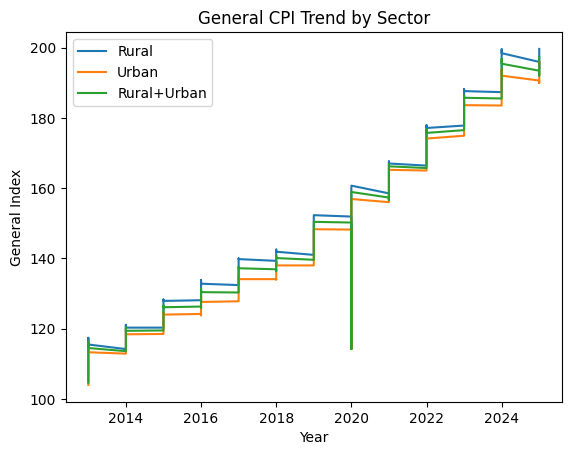

In [50]:
# ---- Line Plot: CPI Trend by Sector ----
plt.figure()
for sector in df["Sector"].unique():
    temp = df[df["Sector"] == sector]
    plt.plot(temp["Year"], temp["General index"], label=sector)

plt.title("General CPI Trend by Sector")
plt.xlabel("Year")
plt.ylabel("General Index")
plt.legend()
plt.show()

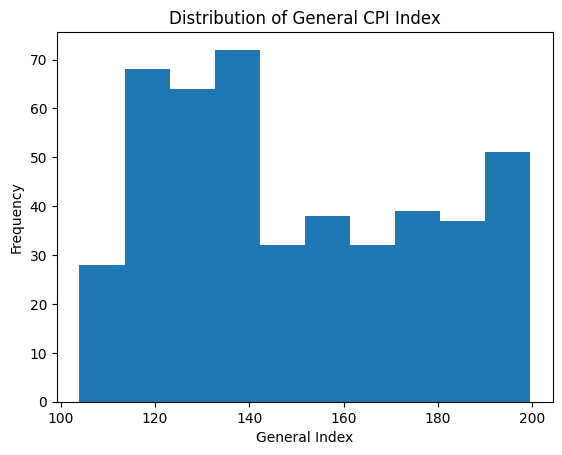

In [51]:
# ---- Histogram: General CPI Distribution ----
plt.figure()
plt.hist(df["General index"])
plt.title("Distribution of General CPI Index")
plt.xlabel("General Index")
plt.ylabel("Frequency")
plt.show()


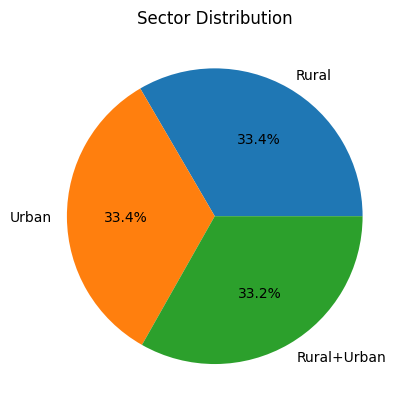

In [52]:
# ---- Pie Chart: Sector Distribution ----
sector_counts = df["Sector"].value_counts()

plt.figure()
plt.pie(sector_counts, labels=sector_counts.index, autopct="%1.1f%%")
plt.title("Sector Distribution")
plt.show()

<Figure size 640x480 with 0 Axes>

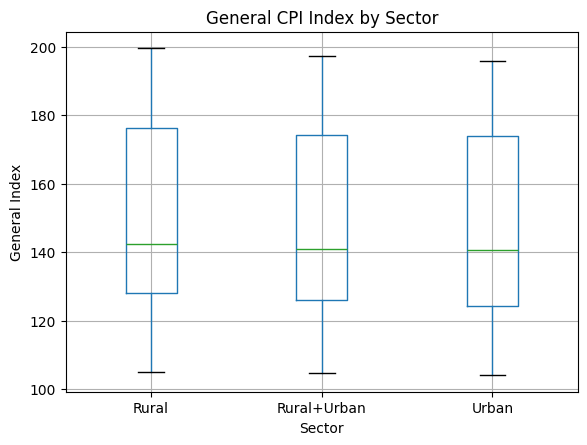

In [53]:
# ---- Boxplot: CPI by Sector ----
plt.figure()
df.boxplot(column="General index", by="Sector")
plt.title("General CPI Index by Sector")
plt.suptitle("")
plt.xlabel("Sector")
plt.ylabel("General Index")
plt.show()

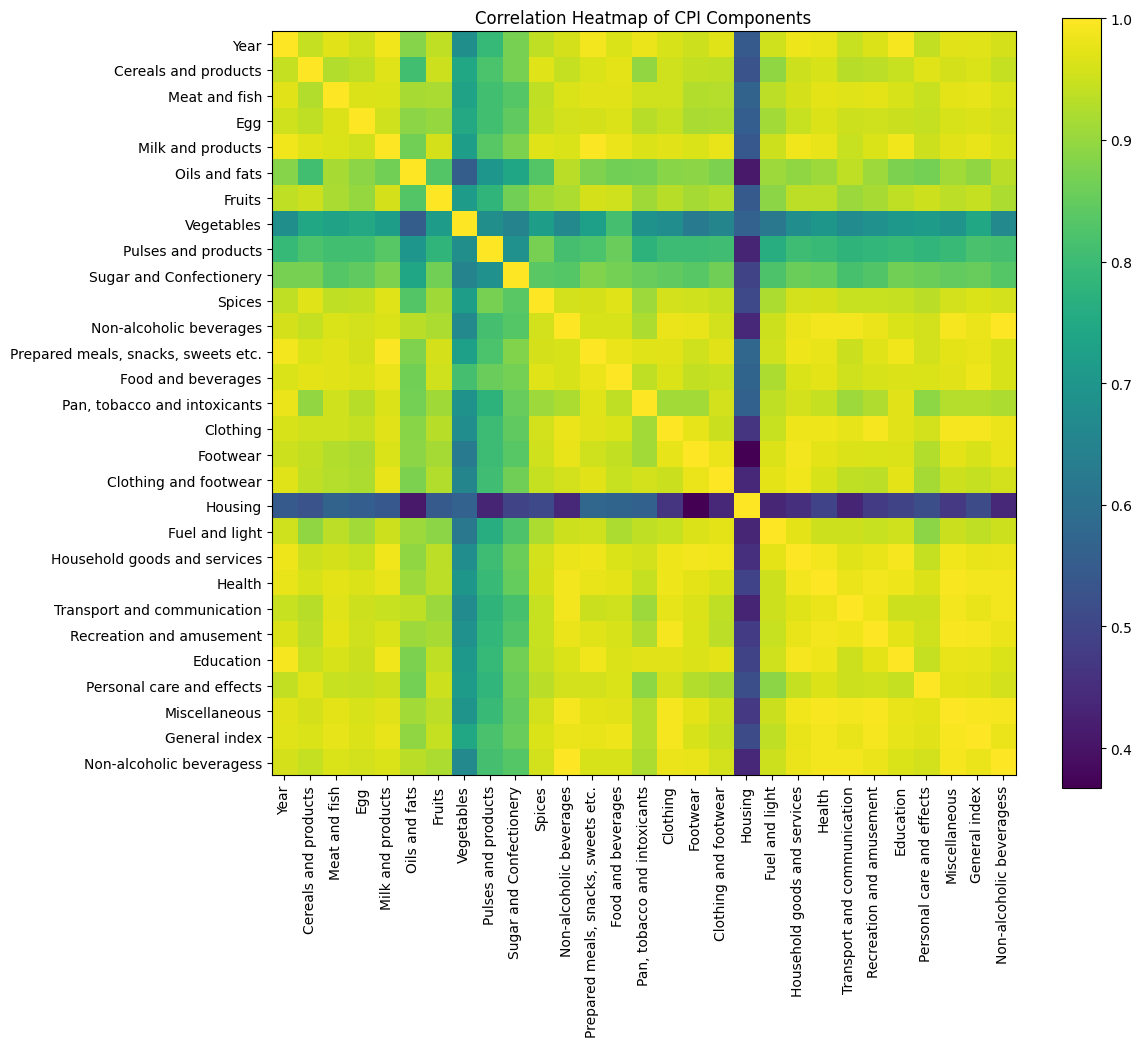

In [55]:
# Select only numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap of CPI Components")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [71]:
df.to_csv("cleaned_consumer_price_index.csv", index=False)

In [72]:
df

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index,Non-alcoholic beveragess
0,0,2013,4,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1,104.8
1,2,2013,4,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0,105.1
2,1,2013,4,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6,104.9
3,0,2013,3,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8,105.1
4,2,2013,3,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7,106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,0,2025,12,197.2,224.2,196.6,190.9,202.4,208.4,196.6,...,183.8,189.0,206.2,178.2,182.9,197.6,254.9,201.4,199.0,191.2
457,2,2025,12,197.9,236.5,201.8,193.3,185.0,205.9,240.4,...,174.5,182.4,200.9,166.9,178.7,194.8,255.7,191.0,195.4,180.8
458,1,2025,12,197.4,228.5,198.6,191.8,196.0,207.2,211.5,...,180.3,185.9,204.2,172.3,180.5,196.0,255.2,196.4,197.3,186.9
459,0,2025,10,197.4,225.2,207.5,191.1,202.4,205.7,201.3,...,184.4,189.3,206.5,178.4,183.1,197.7,255.9,201.7,199.6,191.0


In [60]:
from sklearn.preprocessing import LabelEncoder

le_sector = LabelEncoder()
df["Sector"] = le_sector.fit_transform(df["Sector"])

le_month = LabelEncoder()
df["Month"] = le_month.fit_transform(df["Month"])

In [61]:
# 5. FEATURE SELECTION
# ============================================================

X = df[["Year", "Sector", "Month"]]
y = df["General index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
# 6. LINEAR REGRESSION (BASELINE MODEL)
# ============================================================

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLinear Regression Results")
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))


Linear Regression Results
MSE: 23.251185650564942
R2 Score: 0.9732122916817647


In [65]:
# 7. RANDOM FOREST REGRESSION
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Results")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)


Random Forest Results
MSE: 5.579541266129033
R2 Score: 0.9935718063485941


In [66]:
# 8. XGBOOST REGRESSION
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("\nXGBoost Results")
print("MSE:", xgb_mse)
print("R2 Score:", xgb_r2)


XGBoost Results
MSE: 1.1711387305975902
R2 Score: 0.9986507301955728


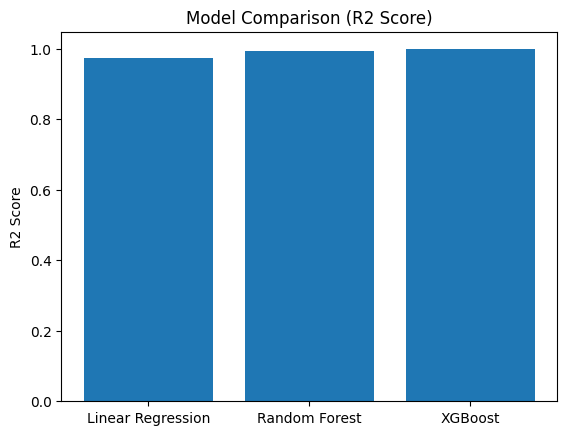

In [67]:
# 9. MODEL COMPARISON
# ============================================================

plt.figure()
plt.bar(
    ["Linear Regression", "Random Forest", "XGBoost"],
    [
        r2_score(y_test, lr_pred),
        rf_r2,
        xgb_r2
    ]
)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

In [69]:
# 10. FUTURE CPI FORECASTING (2026–2030)
# ============================================================

future_years = range(2026, 2031)
future_data = []

for year in future_years:
    for sector in df["Sector"].unique():
        for month in range(12):
            future_data.append([year, sector, month])

future_df = pd.DataFrame(
    future_data,
    columns=["Year", "Sector", "Month"]
)

# Predict future CPI using XGBoost
future_df["Predicted_General_Index"] = xgb_model.predict(future_df)

# Average CPI per year
forecast_summary = future_df.groupby("Year")["Predicted_General_Index"].mean()
print("\nFuture CPI Forecast:")
print(forecast_summary)


Future CPI Forecast:
Year
2026    194.577072
2027    194.577072
2028    194.577072
2029    194.577072
2030    194.577072
Name: Predicted_General_Index, dtype: float32


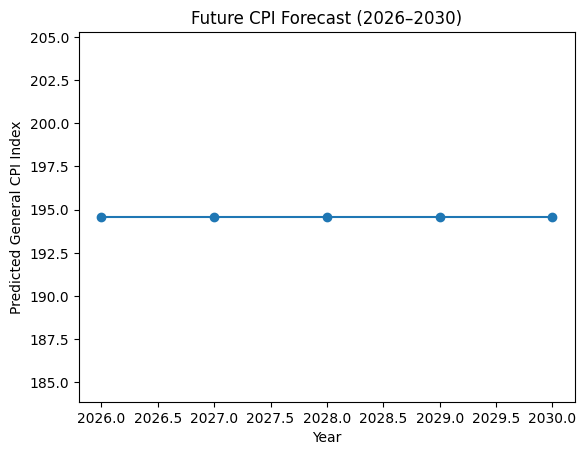

In [70]:
# 11. FORECAST VISUALIZATION
# ============================================================

plt.figure()
plt.plot(
    forecast_summary.index,
    forecast_summary.values,
    marker="o"
)
plt.title("Future CPI Forecast (2026–2030)")
plt.xlabel("Year")
plt.ylabel("Predicted General CPI Index")
plt.show()